In [1]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
def load_trajectory(file_path):
    with open(file_path, 'rb') as f:
        trajectory = pickle.load(f)
    return trajectory


# Inspect datasets

In [12]:
# trajectory = load_trajectory('datasets/sawyer-move-box-v0/successful_trajectories/sawyer-move-box-v0_episode_21.pkl')
# trajectory = load_trajectory('datasets\sawyer-open-drawer-v0\successful_trajectories\sawyer-drawer-open-v0_episode_8.pkl')
trajectory = load_trajectory('datasets/sawyer-move-box-v0/suboptimal_trajectories/sawyer-move-box-v0_episode_1.pkl')
trajectory

[{'observation': array([ 0.17641027,  0.12377577, -0.26387727, -0.06048806,  0.13523339,
         -0.14226918, -0.23689833,  0.01145762,  0.1216081 ,  1.        ],
        dtype=float32),
  'action': array([ 0.00239545,  0.0335418 , -0.00835176,  0.        ,  0.        ]),
  'reward': 0.13009903569459214,
  'done': False,
  'metadata': None},
 {'observation': array([ 0.17658743,  0.12410211, -0.2636645 , -0.06079357,  0.13535118,
         -0.14246218, -0.23738101,  0.01124907,  0.12120233,  0.        ],
        dtype=float32),
  'action': array([ 0.1911342 , -0.1479561 , -0.07670978,  0.        ,  0.        ]),
  'reward': 0.12981269740081824,
  'done': False,
  'metadata': None},
 {'observation': array([ 0.1724574 ,  0.12006053, -0.2618734 , -0.06069868,  0.13531561,
         -0.14239949, -0.23315607,  0.01525509,  0.1194739 ,  0.        ],
        dtype=float32),
  'action': array([ 0.2306423 , -0.13724713, -0.06105478,  0.        ,  0.        ]),
  'reward': 0.13518401304977778,
  '

In [3]:
observations = []
actions = []
rewards = []
dones = []

for items in trajectory:
    obs = items['observation']
    observations.append(obs)
    act = items['action']
    actions.append(act)
    rew = items['reward']
    rewards.append(rew)
    done = items['done']
    dones.append(done)


observations = np.array(observations)
actions = np.array(actions)
rewards = np.array(rewards)
dones = np.array(dones)

print("Observations shape:", observations.shape)
print("Actions shape:", actions.shape)
print("Rewards shape:", rewards.shape)
print("Dones shape:", dones.shape)
print("Horizon (number of steps):", len(trajectory))

Observations shape: (41, 10)
Actions shape: (41, 5)
Rewards shape: (41,)
Dones shape: (41,)
Horizon (number of steps): 41


## Reward inspection

Number of successful trajectories: 50
Trajectory 0: [1.2883376287292034, 1.309989516747339, 1.3139774853204926, 1.3048350821119583, 1.3204047115796969, 1.3736718773156213, 1.3363535600665184, 1.3734515285324238, 1.3698284589062828, 1.368624909509178, 1.3885664112057454, 1.3941153151008558, 1.4003845496908673, 1.418027129914097, 1.4326391940186523, 1.4497820125312586, 1.4375200224047031, 1.4487740058043914, 1.471695932824579, 1.4577306086770134, 1.5007434838730147, 1.5009403938920776, 1.5096461052980974, 1.5285668047519019, 1.5365649610694292, 1.534838873063506, 1.5249554036037547, 1.554733894284377, 1.5612749748117047, 1.5521311462976741, 1.5712904100378675, 1.5622738183036347, 1.5542982876749663, 1.5586852685086459, 1.5781929324918575, 1.5604450789843805]
Trajectory 1: [1.3227624878847162, 1.3242059137765645, 1.3156640873980092, 1.3175553573097147, 1.3329234730506085, 1.339476643015142, 1.3483786112039402, 1.357473911976124, 1.3612399593008875, 1.3794908398180672, 1.4069721053440212, 

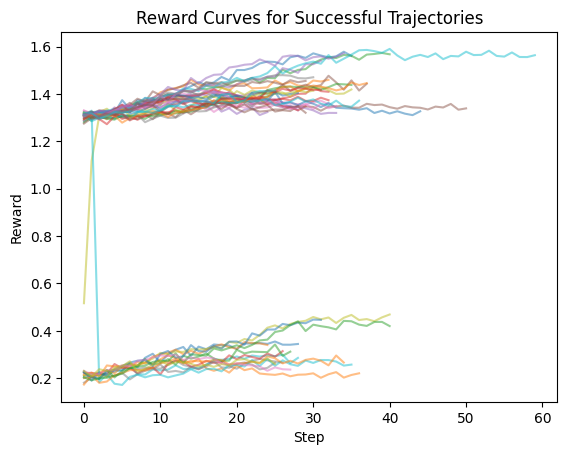

Shortest horizon among successful trajectories: 14 steps
Longest horizon among successful trajectories: 60 steps
sawyer-open-drawer-v0_episode_45.pkl


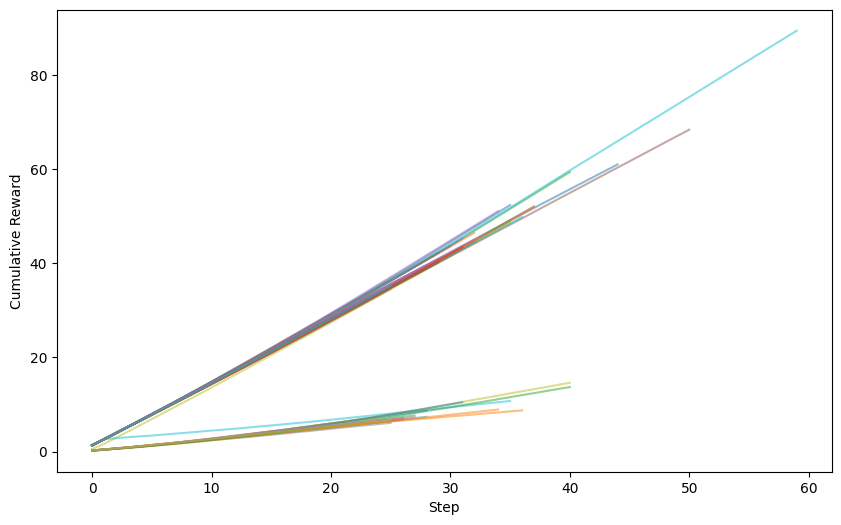

In [4]:
# Now inspect successful trajectories
# successful_trajectories_dir = 'datasets/sawyer-move-box-v0/successful_trajectories'
# successful_trajectories_dir = 'datasets/sawyer-open-drawer-v0/successful_trajectories'
# successful_trajectories_dir = 'datasets/sawyer-pick-lift-banana-v0/successful_trajectories'


# successful_trajectories_dir ='datasets/sawyer-move-box-v0/suboptimal_trajectories'
successful_trajectories_dir = 'datasets/sawyer-open-drawer-v0/suboptimal_trajectories'
# successful_trajectories_dir = 'datasets/sawyer-pick-lift-banana-v0/suboptimal_trajectories'

successful_trajectories = []
coressponding_filenames = []
for filename in os.listdir(successful_trajectories_dir):
    if filename.endswith('.pkl'):
        file_path = os.path.join(successful_trajectories_dir, filename)
        trajectory = load_trajectory(file_path)
        successful_trajectories.append(trajectory)
        coressponding_filenames.append(filename)
print(f"Number of successful trajectories: {len(successful_trajectories)}")


rewards_list = []
for trajectory in successful_trajectories:
    rewards = [step['reward'] for step in trajectory]
    rewards_list.append(rewards)
# Plot reward curves for all successful trajectories
for i, rewards in enumerate(rewards_list):
    print(f"Trajectory {i}: {rewards}")
    plt.plot(rewards, alpha=0.5)
plt.xlabel('Step')
plt.ylabel('Reward')
plt.title('Reward Curves for Successful Trajectories')
plt.show()

# the shortest horizon in the rewards_list
min_horizon = min(len(rewards) for rewards in rewards_list)
print(f"Shortest horizon among successful trajectories: {min_horizon} steps")
max_horizon = max(len(rewards) for rewards in rewards_list)
print(f"Longest horizon among successful trajectories: {max_horizon} steps")

plt.figure(figsize=(10, 6))

cumulative_rewards_list = []
for rewards in rewards_list:
    cumulative_rewards = np.cumsum(rewards)
    cumulative_rewards_list.append(cumulative_rewards)
# Plot cumulative reward curves for all successful trajectories
for cumulative_rewards in cumulative_rewards_list:
    plt.plot(cumulative_rewards, alpha=0.5)
plt.xlabel('Step')
plt.ylabel('Cumulative Reward')
print(coressponding_filenames[48])


## Coverage inspection

Number of successful trajectories: 50


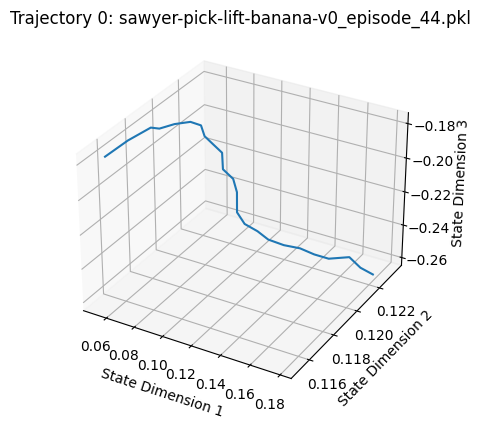

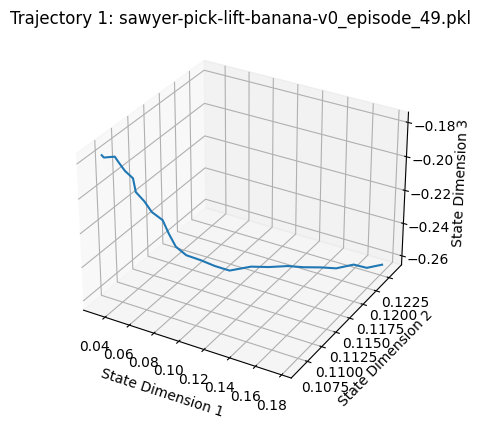

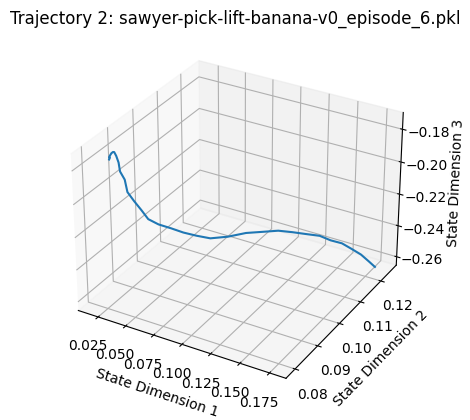

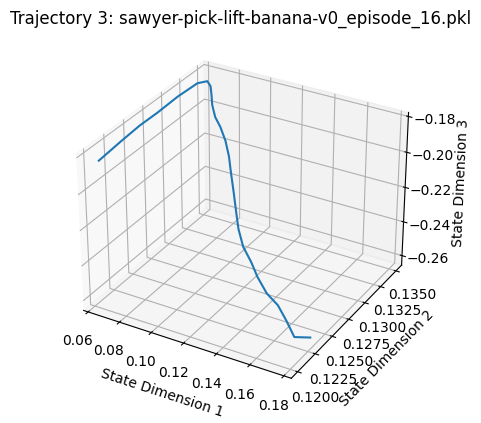

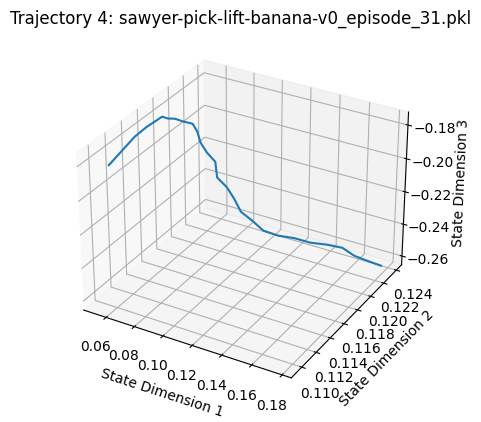

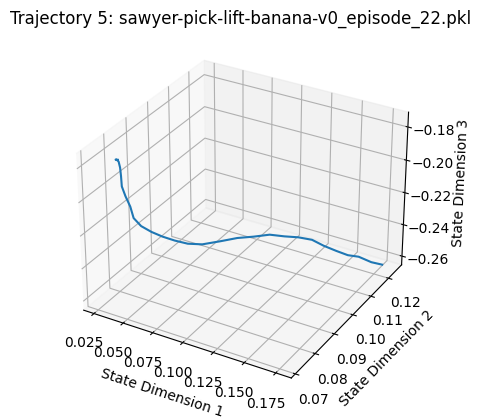

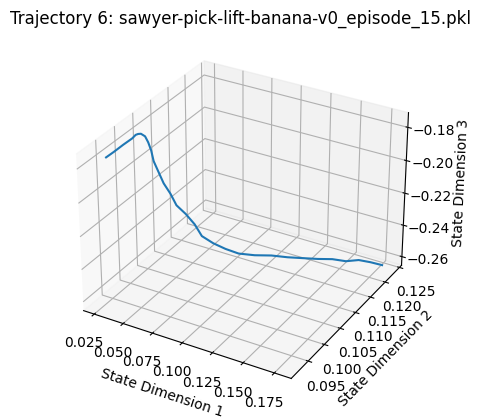

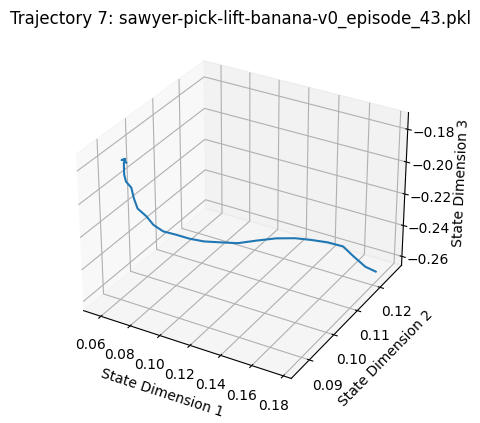

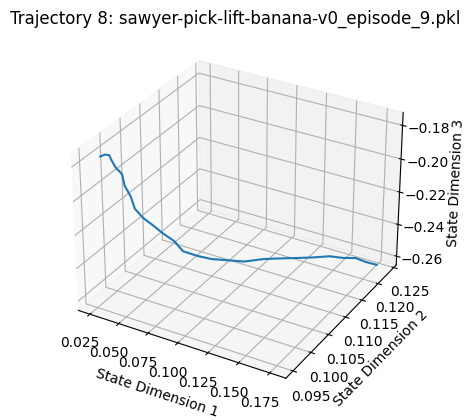

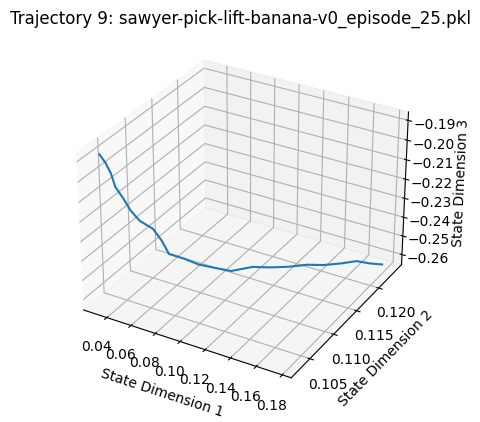

In [7]:
# Visualize trajectores in 3D space using first 3 dimension of the state space

# Now inspect successful trajectories
# successful_trajectories_dir = 'datasets/sawyer-move-box-v0/successful_trajectories'
# successful_trajectories_dir = 'datasets/sawyer-open-drawer-v0/successful_trajectories'
# successful_trajectories_dir = 'datasets/sawyer-pick-lift-banana-v0/successful_trajectories'


# successful_trajectories_dir ='datasets/sawyer-move-box-v0/suboptimal_trajectories'
# successful_trajectories_dir = 'datasets/sawyer-open-drawer-v0/suboptimal_trajectories'
successful_trajectories_dir = 'datasets/sawyer-pick-lift-banana-v0/suboptimal_trajectories'


successful_trajectories = []
coressponding_filenames = []
for filename in os.listdir(successful_trajectories_dir):
    if filename.endswith('.pkl'):
        file_path = os.path.join(successful_trajectories_dir, filename)
        trajectory = load_trajectory(file_path)
        successful_trajectories.append(trajectory)
        coressponding_filenames.append(filename)
print(f"Number of successful trajectories: {len(successful_trajectories)}")

# Comment out if you inspecting individual trajectories, and uncomment the second block if you want to plot all trajectories in the same figure
for i, trajectory in enumerate(successful_trajectories[:10]):
    observations = np.array([step['observation'] for step in trajectory])
    fig = plt.figure() # uncomment this line if you want to plot each trajectory in a separate figure
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(observations[:, 0], observations[:, 1], observations[:, 2])
    ax.set_xlabel('State Dimension 1')
    ax.set_ylabel('State Dimension 2')
    ax.set_zlabel('State Dimension 3')
    ax.set_title(f'Trajectory {i}: {coressponding_filenames[i]}')
    plt.show()

# Plot all trajectories in the same figure
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# for i, trajectory in enumerate(successful_trajectories):
#     observations = np.array([step['observation'] for step in trajectory])
#     ax.plot(observations[:, 0], observations[:, 1], observations[:, 2], alpha=0.5)
# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_zlabel('Z')
# ax.set_title('Successful Trajectories')


# Behavior Cloning with Gaussian Policy

Observations array shape: (2184, 10)
Actions array shape: (2184, 5)
Number of training samples: 1747
Number of test samples: 437
Observation dimension: 10
Action dimension: 5
Observation space min: tensor([-0.0432,  0.0098, -0.2658, -0.0811,  0.1371, -0.1497, -0.2609, -0.0294,
         0.0300,  0.0000], device='cuda:0')
Observation space max: tensor([ 0.1919,  0.2762, -0.0929, -0.0379,  0.3229, -0.0538, -0.0255,  0.1398,
         0.1333,  1.0000], device='cuda:0')
Action space min: tensor([-0.5000, -0.5000, -0.5000,  0.0000,  0.0000], device='cuda:0')
Action space max: tensor([0.5000, 0.5000, 0.5000, 0.0000, 1.0000], device='cuda:0')


 14%|█▍        | 140/1000 [00:00<00:00, 1398.28it/s]

Epoch [100/1000], Loss: 0.0283
Epoch [200/1000], Loss: 0.0255


 30%|██▉       | 295/1000 [00:00<00:00, 1484.52it/s]

Epoch [300/1000], Loss: 0.0241
Epoch [400/1000], Loss: 0.0230


...

Epoch [500/1000], Loss: 0.0222
Epoch [600/1000], Loss: 0.0218


 79%|███████▉  | 788/1000 [00:00<00:00, 1584.49it/s]

Epoch [700/1000], Loss: 0.0215
Epoch [800/1000], Loss: 0.0211


100%|██████████| 1000/1000 [00:00<00:00, 1580.06it/s]

Epoch [900/1000], Loss: 0.0209
Epoch [1000/1000], Loss: 0.0207
Test Loss: 0.0239


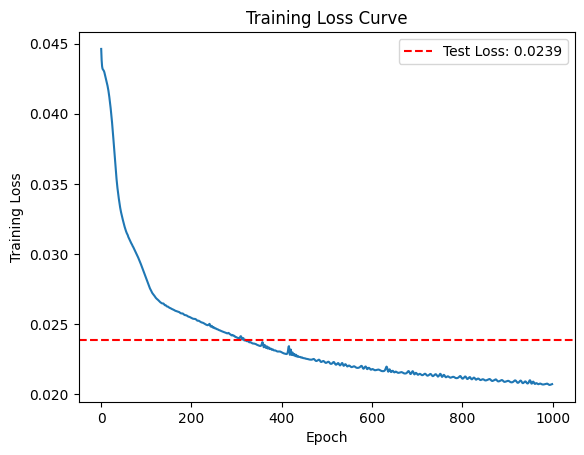

Model saved to mlp_policy.pth


In [25]:
# MLP policy with torch
import torch
import torch.nn as nn
import torch.optim as optim
# tqdm for progress bar
from tqdm import tqdm
import os
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


def load_trajectory(file_path):
    with open(file_path, 'rb') as f:
        trajectory = pickle.load(f)
    return trajectory

# Now doing behavior cloning with gaussian policy
successful_trajectories_dir = 'datasets/sawyer-move-box-v0/successful_trajectories'
# successful_trajectories_dir = 'datasets\sawyer-open-drawer-v0\successful_trajectories'
# successful_trajectories_dir = 'datasets\sawyer-pick-lift-banana-v0\successful_trajectories'

# prepairing dataset for behavior cloning
observations_list = []
actions_list = []
for filename in os.listdir(successful_trajectories_dir):
    if filename.endswith('.pkl'):
        file_path = os.path.join(successful_trajectories_dir, filename)
        trajectory = load_trajectory(file_path)
        for step in trajectory:
            obs = step['observation']
            act = step['action']
            observations_list.append(obs)
            actions_list.append(act)
observations_array = np.array(observations_list)
actions_array = np.array(actions_list)
print("Observations array shape:", observations_array.shape)
print("Actions array shape:", actions_array.shape)


hidden_size = 128
class MLPPolicy(nn.Module):
    def __init__(self, obs_dim, act_dim,hidden_size=64):
        super(MLPPolicy, self).__init__()
        self.fc1 = nn.Linear(obs_dim, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, act_dim)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x
obs_dim = observations_array.shape[1]
act_dim = actions_array.shape[1]
# train on GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
policy = MLPPolicy(obs_dim, act_dim,hidden_size=hidden_size)
policy.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(policy.parameters(), lr=0.001, weight_decay=1e-5)


# train test split
X_train, X_test, y_train, y_test = train_test_split(observations_array, actions_array, test_size=0.2, random_state=42)
# convert to torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
# move tensors to device
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)


# Print statistics about the dataset
print(f"Number of training samples: {X_train_tensor.shape[0]}")
print(f"Number of test samples: {X_test_tensor.shape[0]}")
print(f"Observation dimension: {X_train_tensor.shape[1]}")
print(f"Action dimension: {y_train_tensor.shape[1]}")
# min and max of each dimension of the observation space in a vectorized form
obs_min = torch.min(X_train_tensor, dim=0)[0]
obs_max = torch.max(X_train_tensor, dim=0)[0]
print(f"Observation space min: {obs_min}")
print(f"Observation space max: {obs_max}")
# min and max of each dimension of the action space in a vectorized form
act_min = torch.min(y_train_tensor, dim=0)[0]
act_max = torch.max(y_train_tensor, dim=0)[0]
print(f"Action space min: {act_min}")
print(f"Action space max: {act_max}")

# return True

# training loop
num_epochs = 1000
loss_history = []

for epoch in tqdm(range(num_epochs)):
    policy.train()
    optimizer.zero_grad()
    outputs = policy(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')


# evaluate on test set
policy.eval()
with torch.no_grad():
    test_outputs = policy(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)
    print(f'Test Loss: {test_loss.item():.4f}')


# plot training loss curve
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve')

# draw test loss as a horizontal line
plt.axhline(y=test_loss.item(), color='r', linestyle='--', label=f'Test Loss: {test_loss.item():.4f}')
plt.legend()
plt.show() 


# save the trained model
model_save_path = 'mlp_policy.pth'
torch.save(policy.state_dict(), model_save_path)
print(f'Model saved to {model_save_path}')




# TD3_BC 

## Dataset Preparation

In [41]:
import pickle
import os
import numpy as np

# Convert to D4RL like dataset 

SUPPORTED_TASKS = [
    'sawyer-pick-lift-banana-v0',
    'sawyer-move-box-v0',
    'sawyer-open-drawer-v0'
]

TASK = 'sawyer-open-drawer-v0'


if TASK == 'sawyer-pick-lift-banana-v0':
    dataset_success_path = 'datasets/sawyer-pick-lift-banana-v0/successful_trajectories'
    dataset_suboptimal_path = 'datasets/sawyer-pick-lift-banana-v0/suboptimal_trajectories'
elif TASK == 'sawyer-move-box-v0':
    dataset_success_path = 'datasets/sawyer-move-box-v0/successful_trajectories'
    dataset_suboptimal_path = 'datasets/sawyer-move-box-v0/suboptimal_trajectories'
elif TASK == 'sawyer-open-drawer-v0':
    dataset_success_path = 'datasets/sawyer-open-drawer-v0/successful_trajectories'
    dataset_suboptimal_path = 'datasets/sawyer-open-drawer-v0/suboptimal_trajectories'




successful_trajectories = []
coressponding_filenames = []
for filename in os.listdir(dataset_success_path):
    if filename.endswith('.pkl'):
        file_path = os.path.join(dataset_success_path, filename)
        trajectory = load_trajectory(file_path)
        successful_trajectories.append(trajectory)
        coressponding_filenames.append(filename)


suboptimal_trajectories = []
coressponding_filenames_suboptimal = []
for filename in os.listdir(dataset_suboptimal_path):
    if filename.endswith('.pkl'):
        file_path = os.path.join(dataset_suboptimal_path, filename)
        trajectory = load_trajectory(file_path)
        # Alternate the final done flag in the trajectory to be True, to make it more similar to D4RL dataset
        trajectory[-1]['done'] = True
        suboptimal_trajectories.append(trajectory)
        coressponding_filenames_suboptimal.append(filename)

total_trajectories = successful_trajectories + suboptimal_trajectories

# turn from list of trajectories (list of dict 'observation','action', 'reward','done') to a dictionary with keys: 'observations', 'actions', 'next_observations', 'rewards', 'terminals', where the values are numpy arrays concatenated from all trajectories. The 'next_observations' is the 'observations' shifted by one step, and the last 'next_observations' is the same as the last 'observations' since we don't have the next observation for the last step. The 'terminals' is the same as 'dones'.
dataset_dict = {
    'observations': [],
    'actions': [],
    'next_observations': [],
    'rewards': [],
    'terminals': []
}
for trajectory in total_trajectories:
    observations = np.array([step['observation'] for step in trajectory])
    actions = np.array([step['action'] for step in trajectory])
    rewards = np.array([step['reward'] for step in trajectory])
    dones = np.array([step['done'] for step in trajectory])
    next_observations = np.concatenate((observations[1:], observations[-1:]), axis=0)
    
    dataset_dict['observations'].append(observations)
    dataset_dict['actions'].append(actions)
    dataset_dict['next_observations'].append(next_observations)
    dataset_dict['rewards'].append(rewards)
    dataset_dict['terminals'].append(dones)


# turn the list of numpy arrays in dataset_dict to a single numpy array by concatenating along the first dimension
dataset_dict['observations'] = np.concatenate(dataset_dict['observations'], axis=0)
dataset_dict['actions'] = np.concatenate(dataset_dict['actions'], axis=0)
dataset_dict['next_observations'] = np.concatenate(dataset_dict['next_observations'], axis=0)
dataset_dict['rewards'] = np.concatenate(dataset_dict['rewards'], axis=0)
dataset_dict['terminals'] = np.concatenate(dataset_dict['terminals'], axis=0)



print(f"Number of trajectories in the dataset: {len(total_trajectories)}")
print(f"Total number of samples in the dataset: {sum(len(traj) for traj in total_trajectories)}")


Number of trajectories in the dataset: 100
Total number of samples in the dataset: 3753


In [42]:

from utils import ReplayBuffer  

obs_dim = dataset_dict['observations'].shape[1]
act_dim = dataset_dict['actions'].shape[1]
max_action = np.max(dataset_dict['actions'], axis=0)
# alternate max_action to be 1 since we will normalize the action space to be between -1 and 1 when training the policy
max_action = np.ones_like(max_action)

print(f"Observation dimension: {obs_dim}")
print(f"Action dimension: {act_dim}")
print(f"Max action value: {max_action}")

replay_buffer = ReplayBuffer(obs_dim, act_dim, max_size=5000)
replay_buffer.convert_D4RL(dataset_dict)


Observation dimension: 10
Action dimension: 5
Max action value: [1. 1. 1. 1. 1.]


In [43]:
# print statistics of the reward distribution in the dataset
print(f"Reward distribution: mean={np.mean(dataset_dict['rewards'])}, std={np.std(dataset_dict['rewards'])}, min={np.min(dataset_dict['rewards'])}, max={np.max(dataset_dict['rewards'])}")

# Print statistics of the cumulative reward distribution in the dataset. Note that the cumulative reward is the sum of rewards from the current step to the end of the trajectory, so we need to compute it for each trajectory separately and then concatenate them together to get the cumulative reward distribution for the whole dataset.
cumulative_rewards_list = []
for trajectory in total_trajectories:
    rewards = np.array([step['reward'] for step in trajectory])
    cumulative_rewards = np.cumsum(rewards[::-1])[::-1]  # compute cumulative reward from the end of the trajectory
    cumulative_rewards_list.append(cumulative_rewards)
cumulative_rewards_array = np.concatenate(cumulative_rewards_list, axis=0)
print(f"Cumulative reward distribution: mean={np.mean(cumulative_rewards_array)}, std={np.std(cumulative_rewards_array)}, min={np.min(cumulative_rewards_array)}, max={np.max(cumulative_rewards_array)}")

Reward distribution: mean=1.943588941783215, std=9.836423128813365, min=0.04565622633746935, max=84.59781286111087
Cumulative reward distribution: mean=69.43162077568057, std=49.29843771782174, min=0.22072165888116818, max=190.290367672937


## TD3_BC

In [44]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class Actor(nn.Module):
	def __init__(self, state_dim, action_dim, max_action):
		super(Actor, self).__init__()

		self.l1 = nn.Linear(state_dim, 256)
		self.l2 = nn.Linear(256, 256)
		self.l3 = nn.Linear(256, action_dim)
		
		self.max_action = torch.FloatTensor(max_action).to(device)
		

	def forward(self, state):
		a = F.relu(self.l1(state))
		a = F.relu(self.l2(a))
		return self.max_action * torch.tanh(self.l3(a))


class Critic(nn.Module):
	def __init__(self, state_dim, action_dim):
		super(Critic, self).__init__()

		# Q1 architecture
		self.l1 = nn.Linear(state_dim + action_dim, 256)
		self.l2 = nn.Linear(256, 256)
		self.l3 = nn.Linear(256, 1)

		# Q2 architecture
		self.l4 = nn.Linear(state_dim + action_dim, 256)
		self.l5 = nn.Linear(256, 256)
		self.l6 = nn.Linear(256, 1)


	def forward(self, state, action):
		sa = torch.cat([state, action], 1)

		q1 = F.relu(self.l1(sa))
		q1 = F.relu(self.l2(q1))
		q1 = self.l3(q1)

		q2 = F.relu(self.l4(sa))
		q2 = F.relu(self.l5(q2))
		q2 = self.l6(q2)
		return q1, q2


	def Q1(self, state, action):
		sa = torch.cat([state, action], 1)

		q1 = F.relu(self.l1(sa))
		q1 = F.relu(self.l2(q1))
		q1 = self.l3(q1)
		return q1


class TD3_BC(object):
	def __init__(
		self,
		state_dim,
		action_dim,
		max_action,
		discount=0.99,
		tau=0.005,
		policy_noise=0.2,
		noise_clip=0.5,
		policy_freq=1,
		alpha=2.5,
	):

		self.actor = Actor(state_dim, action_dim, max_action).to(device)
		self.actor_target = copy.deepcopy(self.actor)
		self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=3e-4)

		self.critic = Critic(state_dim, action_dim).to(device)
		self.critic_target = copy.deepcopy(self.critic)
		self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=3e-4)

		self.max_action = torch.FloatTensor(max_action).to(device)
		self.discount = discount
		self.tau = tau
		self.policy_noise = policy_noise
		self.noise_clip = noise_clip
		self.policy_freq = policy_freq
		self.alpha = alpha

		self.total_it = 0


	def select_action(self, state):
		state = torch.FloatTensor(state.reshape(1, -1)).to(device)
		return self.actor(state).cpu().data.numpy().flatten()


	def train(self, replay_buffer, batch_size=256):
		self.total_it += 1

		# Sample replay buffer 
		state, action, next_state, reward, not_done = replay_buffer.sample(batch_size)

		with torch.no_grad():
			# Select action according to policy and add clipped noise
			noise = (torch.randn_like(action) * self.policy_noise).clamp(-self.noise_clip, self.noise_clip)

			next_action = (
				self.actor_target(next_state) + noise
			).clamp(-self.max_action, self.max_action)

			# Compute the target Q value
			target_Q1, target_Q2 = self.critic_target(next_state, next_action)
			target_Q = torch.min(target_Q1, target_Q2)
			target_Q = reward + not_done * self.discount * target_Q

		# Get current Q estimates
		current_Q1, current_Q2 = self.critic(state, action)

		# Compute critic loss
		critic_loss = F.mse_loss(current_Q1, target_Q) + F.mse_loss(current_Q2, target_Q)

		# Optimize the critic
		self.critic_optimizer.zero_grad()
		critic_loss.backward()
		self.critic_optimizer.step()

		# Delayed policy updates
		if self.total_it % self.policy_freq == 0:

			# Compute actor loss
			pi = self.actor(state)
			Q = self.critic.Q1(state, pi)
			lmbda = self.alpha/Q.abs().mean().detach()

			bc_loss = F.mse_loss(pi, action)

			actor_loss = -lmbda * Q.mean() + bc_loss 
			
			# Optimize the actor 
			self.actor_optimizer.zero_grad()
			actor_loss.backward()
			self.actor_optimizer.step()

			# Update the frozen target models
			for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
				target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

			for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
				target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

		return actor_loss.item(), critic_loss.item(), bc_loss.item(), Q.mean().item()


	def save(self, filename):
		torch.save(self.critic.state_dict(), filename + "_critic")
		torch.save(self.critic_optimizer.state_dict(), filename + "_critic_optimizer")
		
		torch.save(self.actor.state_dict(), filename + "_actor")
		torch.save(self.actor_optimizer.state_dict(), filename + "_actor_optimizer")


	def load(self, filename):
		self.critic.load_state_dict(torch.load(filename + "_critic"))
		self.critic_optimizer.load_state_dict(torch.load(filename + "_critic_optimizer"))
		self.critic_target = copy.deepcopy(self.critic)

		self.actor.load_state_dict(torch.load(filename + "_actor"))
		self.actor_optimizer.load_state_dict(torch.load(filename + "_actor_optimizer"))
		self.actor_target = copy.deepcopy(self.actor)


## Training loop

Using device: cuda


  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:29<00:00, 334.37it/s]


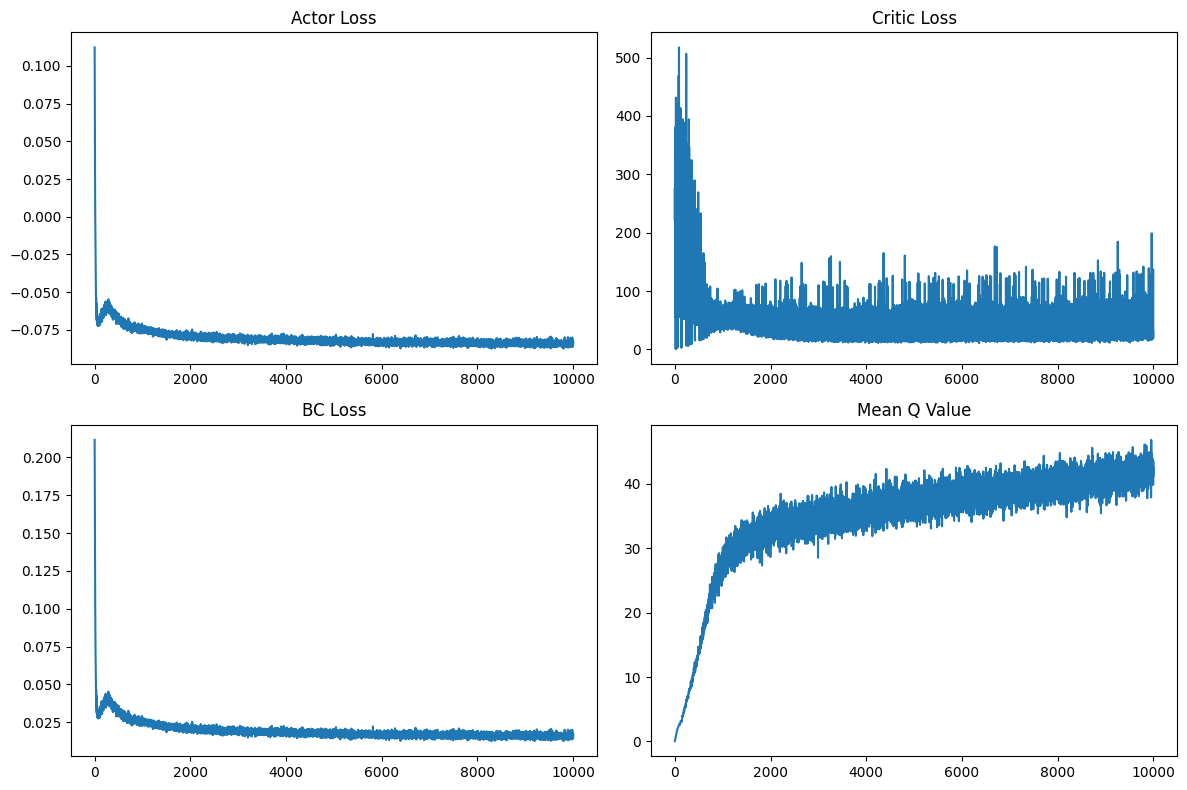

In [ ]:
import numpy as np
import torch
import argparse
import os
# tqdm for progress bar
from tqdm import tqdm

SEED=0
EVAL_FREQ=1000
if TASK == 'sawyer-open-drawer-v0':
    MAX_TIMESTEPS=10000
else:
    MAX_TIMESTEPS=20000


EXPL_NOISE=0.1
BATCH_SIZE=256
GAMMA=0.99
TAU=0.005
POLICY_NOISE=0.2
NOISE_CLIP=0.5
POLICY_FREQ=1

if TASK == 'sawyer-pick-lift-banana-v0':
    ALPHA=0.01 # 0.001 for pick-lift-banana, 0.1 for move-box, 2.5 for open-drawer
elif TASK == 'sawyer-move-box-v0':
    ALPHA=0.1
elif TASK == 'sawyer-open-drawer-v0':
    ALPHA=0.1

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if not os.path.exists("./results"):
    os.makedirs("./results")

if not os.path.exists("./models"):
    os.makedirs("./models")

torch.manual_seed(SEED)
np.random.seed(SEED)


kwargs = {
    "state_dim": obs_dim,
    "action_dim": act_dim,
    "max_action": max_action,
    "discount": GAMMA,
    "tau": TAU,
    # TD3
    "policy_noise": POLICY_NOISE ,
    "noise_clip": NOISE_CLIP ,
    "policy_freq": POLICY_FREQ,
    # TD3 + BC
    "alpha": ALPHA
}

policy = TD3_BC(**kwargs)
actor_loss_history = []
critic_loss_history = []
bc_loss_history = []
q_mean_history = []
for i in tqdm(range(MAX_TIMESTEPS)):
    
    actor_loss, critic_loss, bc_loss, q_mean = policy.train(replay_buffer, BATCH_SIZE)
    actor_loss_history.append(actor_loss)
    critic_loss_history.append(critic_loss)
    bc_loss_history.append(bc_loss)
    q_mean_history.append(q_mean)

# plot the loss curves
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(actor_loss_history)
plt.title('Actor Loss')
plt.subplot(2, 2, 2)
plt.plot(critic_loss_history)
plt.title('Critic Loss')
plt.subplot(2, 2, 3)
plt.plot(bc_loss_history)
plt.title('BC Loss')
plt.subplot(2, 2, 4)
plt.plot(q_mean_history)
plt.title('Mean Q Value')
plt.tight_layout()
plt.show()



In [49]:
if TASK == 'sawyer-pick-lift-banana-v0':
    save_path = './models/sawyer-pick-lift-banana-v0/td3_bc_sawyer_pick_lift_banana.pth'
elif TASK == 'sawyer-move-box-v0':
    save_path = './models/sawyer-move-box-v0/td3_bc_sawyer_move_box.pth'
elif TASK == 'sawyer-open-drawer-v0':
    save_path = './models/sawyer-open-drawer-v0/td3_bc_sawyer_open_drawer.pth'

# make subdirectories  inside ./models if they don't exist
if not os.path.exists('./models/sawyer-pick-lift-banana-v0'):
    os.makedirs('./models/sawyer-pick-lift-banana-v0')
if not os.path.exists('./models/sawyer-move-box-v0'):
    os.makedirs('./models/sawyer-move-box-v0')
if not os.path.exists('./models/sawyer-open-drawer-v0'):
    os.makedirs('./models/sawyer-open-drawer-v0')

policy.save(save_path)
print(f'Model saved to {save_path}')

Model saved to ./models/sawyer-open-drawer-v0/td3_bc_sawyer_open_drawer.pth


In [50]:
# Load model in a standalone way

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class Actor(nn.Module):
	def __init__(self, state_dim, action_dim, max_action=1.0):
		super(Actor, self).__init__()

		self.l1 = nn.Linear(state_dim, 256)
		self.l2 = nn.Linear(256, 256)
		self.l3 = nn.Linear(256, action_dim)
		
		self.max_action = torch.FloatTensor(max_action).to(device)
		

	def forward(self, state):
		a = F.relu(self.l1(state))
		a = F.relu(self.l2(a))
		return self.max_action * torch.tanh(self.l3(a))
	
act_dim = 5
obs_dim = 10
max_action = np.ones(act_dim)
policy = Actor(10, act_dim, max_action).to(device)

if TASK == 'sawyer-pick-lift-banana-v0':
    model_load_path = './models/sawyer-pick-lift-banana-v0/td3_bc_sawyer_pick_lift_banana.pth_actor'
elif TASK == 'sawyer-move-box-v0':
    model_load_path = './models/sawyer-move-box-v0/td3_bc_sawyer_move_box.pth_actor'
elif TASK == 'sawyer-open-drawer-v0':
    model_load_path = './models/sawyer-open-drawer-v0/td3_bc_sawyer_open_drawer.pth_actor'
    
policy.load_state_dict(torch.load(model_load_path))
print(f'Model loaded from {model_load_path}')

#sampling action from the loaded policy
state = np.random.randn(obs_dim)
state_tensor = torch.FloatTensor(state.reshape(1, -1)).to(device)
action = policy(state_tensor).cpu().data.numpy().flatten()
print(f"Sampled action: {action}")


Model loaded from ./models/sawyer-open-drawer-v0/td3_bc_sawyer_open_drawer.pth_actor
Sampled action: [-0.9609722  -0.6264257  -0.9429816   0.44358295  1.        ]


# Visualization

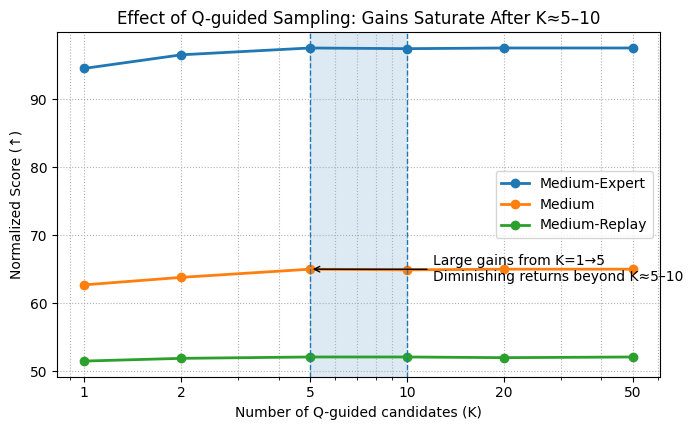

Saved figure to: ablation_q_guided_sampling.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Data (from your ablation table)
# -----------------------------
K = np.array([1, 2, 5, 10, 20, 50])

scores = {
    "Medium-Expert": np.array([94.5, 96.5, 97.5, 97.4, 97.5, 97.5]),
    "Medium":        np.array([62.7, 63.8, 65.0, 64.9, 65.0, 65.0]),
    "Medium-Replay": np.array([51.5, 51.9, 52.1, 52.1, 52.0, 52.1]),
}

# -----------------------------
# Plot: shows "early gains then saturation"
# -----------------------------
plt.figure(figsize=(7.2, 4.4))

# Lines
for name, y in scores.items():
    plt.plot(K, y, marker="o", linewidth=2, label=name)

# Use log-scale on x so spacing visually reflects "1->2->5->10->20->50"
plt.xscale("log")
plt.xticks(K, [str(k) for k in K])

plt.xlabel("Number of Q-guided candidates (K)")
plt.ylabel("Normalized Score (↑)")
plt.title("Effect of Q-guided Sampling: Gains Saturate After K≈5–10")

# --- Visual cues to emphasize the conclusion ---
# (1) Highlight "sweet spot" region
plt.axvspan(5, 10, alpha=0.15)  # no color specified; uses default cycle alpha overlay

# (2) Vertical line at K=5 and K=10 to guide the eye
plt.axvline(5, linestyle="--", linewidth=1)
plt.axvline(10, linestyle="--", linewidth=1)

# (3) Annotation: "big jump then plateau"
# Place it near Medium curve (tweak coordinates if needed)
# plt.annotate(
#     "Large gains from K=1→5\nDiminishing returns beyond K≈5–10",
#     xy=(5, scores["Medium"][2]),
#     xytext=(12, scores["Medium"][2] - 1.8),
#     arrowprops=dict(arrowstyle="->", linewidth=1),
# )

plt.grid(True, which="both", linestyle=":", linewidth=0.8)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig("ablation_q_guided_sampling.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to: ablation_q_guided_sampling.png")

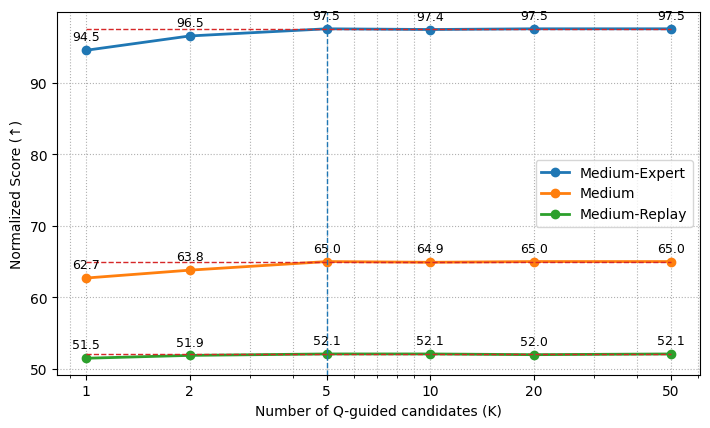

Saved figure to: ablation_q_guided_sampling_with_values.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt

K = np.array([1, 2, 5, 10, 20, 50])

scores = {
    "Medium-Expert": np.array([94.5, 96.5, 97.5, 97.4, 97.5, 97.5]),
    "Medium":        np.array([62.7, 63.8, 65.0, 64.9, 65.0, 65.0]),
    "Medium-Replay": np.array([51.5, 51.9, 52.1, 52.1, 52.0, 52.1]),
}

plt.figure(figsize=(7.2, 4.4))

for name, y in scores.items():
    line, = plt.plot(K, y, marker="o", linewidth=2, label=name)

    # --- show numeric value on top of each marker ---
    for x_i, y_i in zip(K, y):
        plt.annotate(
            f"{y_i:.1f}",            # text
            (x_i, y_i),              # point to label
            textcoords="offset points",
            xytext=(0, 7),           # (dx, dy) in points -> above the marker
            ha="center",
            fontsize=9,
        )

plt.xscale("log")
plt.xticks(K, [str(k) for k in K])

plt.xlabel("Number of Q-guided candidates (K)")
plt.ylabel("Normalized Score (↑)")
# plt.title("Effect of Q-guided Sampling: Gains Saturate After K≈5–10")

# plt.axvspan(5, 10, alpha=0.15)
plt.axvline(5, linestyle="--", linewidth=1)
# plt.axvline(10, linestyle="--", linewidth=1)
x_min, x_max = 1, K.max()

plt.hlines(y=52.1, xmin=x_min, xmax=x_max, linestyles="--", linewidth=1,colors="tab:red")
plt.hlines(y=65.0, xmin=x_min, xmax=x_max, linestyles="--", linewidth=1,colors="tab:red")
plt.hlines(y=97.5, xmin=x_min, xmax=x_max, linestyles="--", linewidth=1,colors="tab:red")

plt.grid(True, which="both", linestyle=":", linewidth=0.8)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig("ablation_q_guided_sampling_with_values.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to: ablation_q_guided_sampling_with_values.png")

/tmp/ipykernel_2343358/2411705678.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


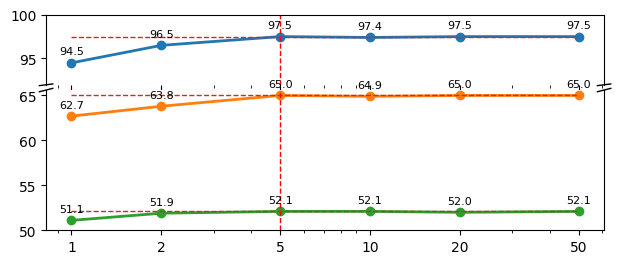

Saved figure to: ablation_q_guided_sampling_broken_y.pdf


In [24]:
import numpy as np
import matplotlib.pyplot as plt

K = np.array([1, 2, 5, 10, 20, 50])

scores = {
    "Medium-Expert": np.array([94.5, 96.5, 97.5, 97.4, 97.5, 97.5]),
    "Medium":        np.array([62.7, 63.8, 65.0, 64.9, 65.0, 65.0]),
    "Medium-Replay": np.array([51.1, 51.9, 52.1, 52.1, 52.0, 52.1]),
}

# -----------------------------
# Trick 1: "zoomed" y-axis (broken y-axis) to:
#   - make the K=1 -> saturation gaps look bigger
#   - keep Medium-Expert closer to the others to save vertical space
# -----------------------------
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(7.2, 2.8),
    gridspec_kw={"height_ratios": [1, 2], "hspace": 0.05}
)

# Helper for plotting + value labels
def plot_with_labels(ax, name, y):
    ax.plot(K, y, marker="o", linewidth=2, label=name)
    for x_i, y_i in zip(K, y):
        ax.annotate(
            f"{y_i:.1f}",
            (x_i, y_i),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            fontsize=8,
        )

for name, y in scores.items():
    plot_with_labels(ax_top, name, y)
    plot_with_labels(ax_bot, name, y)

# Log x + ticks
ax_bot.set_xscale("log")
ax_bot.set_xticks(K)
ax_bot.set_xticklabels([str(k) for k in K])

# Vertical line at K=5 (both axes)
for ax in (ax_top, ax_bot):
    ax.axvline(5, linestyle="--", linewidth=1,color="red")

# Saturation horizontal lines (draw only on the relevant axis region)
x_min, x_max = 1, K.max()
# Medium-Replay saturation ~52.1 and Medium saturation ~65.0 go to bottoma
ax_bot.hlines(y=52.1, xmin=x_min, xmax=x_max, linestyles="--", linewidth=1, colors="tab:red")
ax_bot.hlines(y=65.0, xmin=x_min, xmax=x_max, linestyles="--", linewidth=1, colors="tab:red")
# Medium-Expert saturation ~97.5 goes to top
ax_top.hlines(y=97.5, xmin=x_min, xmax=x_max, linestyles="--", linewidth=1, colors="tab:red")

# -----------------------------
# IMPORTANT: Set y-lims to "stretch" the gaps
# You can tweak these to exaggerate the improvements more/less.
# -----------------------------
ax_bot.set_ylim(50, 65.6)   # zoom on Medium / Medium-Replay band
ax_top.set_ylim(92, 100)   # zoom on Medium-Expert band

# Make the "break" visible
ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False)  # no top tick labels
ax_bot.xaxis.tick_bottom()

# Diagonal break marks
d = 0.012  # size of diagonal lines
kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=1)
ax_top.plot((-d, +d), (-d, +d), **kwargs)              # top-left
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)        # top-right
kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)        # bottom-left
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right

# Labels
# ax_bot.set_xlabel("Number of Q-guided candidates (K)")
# ax_bot.set_ylabel("Normalized Score (↑)")
ax_top.set_ylabel("")  # keep clean (optional)

# Disable grid (cleaner for paper)
ax_top.grid(False)
ax_bot.grid(False)

# Legend: put it once (top axis), and keep it compact
# ax_top.legend(frameon=True, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("ablation_q_guided_sampling_broken_y.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to: ablation_q_guided_sampling_broken_y.pdf")

/tmp/ipykernel_716973/2289934074.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


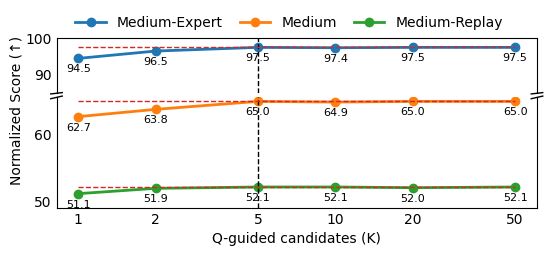

In [1]:
import numpy as np
import matplotlib.pyplot as plt

K = np.array([1, 2, 5, 10, 20, 50])

# use font times new roman for the plot

scores = {
    "Medium-Expert": np.array([94.5, 96.5, 97.5, 97.4, 97.5, 97.5]),
    "Medium":        np.array([62.7, 63.8, 65.0, 64.9, 65.0, 65.0]),
    "Medium-Replay": np.array([51.1, 51.9, 52.1, 52.1, 52.0, 52.1]),
}

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(6.2, 2.2),
    gridspec_kw={"height_ratios": [1, 2], "hspace": 0.05}
)

def plot_with_labels(ax, name, y):
    ax.plot(K, y, marker="o", linewidth=2, label=name)
    for x_i, y_i in zip(K, y):
        ax.annotate(
            f"{y_i:.1f}",
            (x_i, y_i),
            textcoords="offset points",
            xytext=(0, -10),
            ha="center",
            fontsize=8,
        )

for name, y in scores.items():
    plot_with_labels(ax_top, name, y)
    plot_with_labels(ax_bot, name, y)

# Log x + ticks
ax_bot.set_xscale("log")
ax_bot.set_xticks(K)
ax_bot.set_xticklabels([str(k) for k in K])

# ---- REMOVE "tick marks inside chart" ----
# Turn ticks outward and shorten them (or set length=0 to remove completely).
for ax in (ax_top, ax_bot):
    ax.tick_params(axis="both", which="both", direction="out", length=0)  # <- key line
    ax.minorticks_off()  # also disable minor ticks (common culprit on log scale)

# Vertical line at K=5
for ax in (ax_top, ax_bot):
    ax.axvline(5, linestyle="--", linewidth=1, color="black")

# Saturation horizontal lines
x_min, x_max = 1, K.max()
ax_bot.hlines(y=52.1, xmin=x_min, xmax=x_max, linestyles="--", linewidth=1, colors="tab:red")
ax_bot.hlines(y=65.0, xmin=x_min, xmax=x_max, linestyles="--", linewidth=1, colors="tab:red")
ax_top.hlines(y=97.5, xmin=x_min, xmax=x_max, linestyles="--", linewidth=1, colors="tab:red")

# y-lims
ax_bot.set_ylim(49, 65.6)
ax_top.set_ylim(85, 100)

# Broken axis styling
ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False)
ax_bot.xaxis.tick_bottom()

# Diagonal break marks
d = 0.012
kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=1)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# No grid
ax_top.grid(False)
ax_bot.grid(False)

handles, labels = ax_top.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),   # tweak y (1.02~1.08) if needed
    ncol=3,
    frameon=False,
    fontsize=10,
    handlelength=2.2,
    columnspacing=1.2,
)

ax_bot.set_xlabel("Q-guided candidates (K)", fontsize=10)

# ax_bot.set_ylabel("Normalized Score (↑)")

# Remove axis-specific ylabels
ax_top.set_ylabel("")
ax_bot.set_ylabel("")

# Add one shared y-label for the whole figure
fig.supylabel("Normalized Score (↑)", x=+0.05, y=0.55,fontsize=10)  # tweak x/y to position the label; adjust fontsize as needed

# set font size of the shared y-label and x-label

plt.tight_layout()
plt.savefig("ablation_q_guided_sampling_broken_y.pdf", dpi=300, bbox_inches="tight")
plt.show()